# Stage 3: Similarity Explanation

For any two players A and B, we decompose *why* they are similar into per-feature contributions.

**Method — no black box:**
1. Retrieve each player's 21-feature vector from the scaled profile matrix (same StandardScaler as clustering)
2. L2-normalise both vectors
3. Elementwise product → per-feature contribution score
4. Sum of all contributions = cosine similarity (identity, not an approximation)
5. Rank contributions: top = key similarities, bottom = key differentiators

**Why elementwise product = contribution:**
Cosine similarity is the dot product of two L2-normalised vectors:
```
cos(A, B) = Σ (â_i × b̂_i)
```
Each term `â_i × b̂_i` is one feature's additive contribution. The sum recovers the exact cosine similarity — no approximation, fully decomposable.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load profiles and fit the same scaler used in clustering
profiles = pd.read_csv('../data/player_profiles_clustered.csv')

FEATURE_COLS = [c for c in profiles.columns
                if c not in ('player_id', 'player_name', 'team_name', 'era',
                             'minutes_played', 'cluster', 'cluster_label', 'umap_x', 'umap_y')]

X = profiles[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

FEATURE_LABELS = {
    'pass_completion_pct':       'Pass Completion %',
    'progressive_passes_p90':    'Progressive Passes /90',
    'pct_passes_forward':        'Forward Pass %',
    'pct_passes_sideways':       'Sideways Pass %',
    'pct_passes_backward':       'Backward Pass %',
    'avg_pass_distance':         'Avg Pass Distance',
    'key_passes_p90':            'Key Passes /90',
    'crosses_p90':               'Crosses /90',
    'long_balls_p90':            'Long Balls /90',
    'pressures_p90':             'Pressures /90',
    'pressure_success_rate':     'Pressure Success Rate',
    'tackles_p90':               'Tackles /90',
    'interceptions_p90':         'Interceptions /90',
    'aerial_duels_p90':          'Aerial Duels /90',
    'progressive_carries_p90':   'Progressive Carries /90',
    'dribble_success_rate':      'Dribble Success Rate',
    'carries_final_third_p90':   'Carries into Final Third /90',
    'xg_p90':                    'xG /90',
    'xg_per_shot':               'xG per Shot',
    'shots_p90':                 'Shots /90',
    'box_touches_p90':           'Box Touches /90',
}

print(f"Profiles loaded: {len(profiles):,} players")
print(f"Feature columns: {len(FEATURE_COLS)}")

Profiles loaded: 4,475 players
Feature columns: 21


## Core functions

In [2]:
def get_player(name):
    """Return the profile row for a player by name substring. Picks most-minutes row if multiple."""
    matches = profiles[profiles['player_name'].str.contains(name, case=False, na=False)]
    if len(matches) == 0:
        raise ValueError(f'Player not found: {name}')
    idx = matches['minutes_played'].idxmax()
    return profiles.loc[idx], idx


def explain_similarity(name_a, name_b):
    """
    Decompose the cosine similarity between two players into per-feature contributions.

    Returns
    -------
    df       : DataFrame sorted by contribution descending — feature, label,
               player_a_raw, player_b_raw, contribution
    cos_sim  : float — overall cosine similarity (= sum of contributions)
    row_a    : player A profile row
    row_b    : player B profile row
    """
    row_a, idx_a = get_player(name_a)
    row_b, idx_b = get_player(name_b)

    v_a = X_scaled[idx_a]
    v_b = X_scaled[idx_b]

    # L2-normalise
    v_a_norm = v_a / np.linalg.norm(v_a)
    v_b_norm = v_b / np.linalg.norm(v_b)

    # Per-feature contribution; sum = cosine similarity
    contributions = v_a_norm * v_b_norm
    cos_sim = float(contributions.sum())

    df = pd.DataFrame({
        'feature':      FEATURE_COLS,
        'label':        [FEATURE_LABELS[f] for f in FEATURE_COLS],
        'player_a_raw': row_a[FEATURE_COLS].values,
        'player_b_raw': row_b[FEATURE_COLS].values,
        'contribution': contributions,
    })
    df = df.sort_values('contribution', ascending=False).reset_index(drop=True)
    return df, cos_sim, row_a, row_b


def plot_similarity(name_a, name_b, top_n=10, bottom_n=5, save_path=None):
    """Horizontal bar chart: top_n similarities (green) and bottom_n differences (red)."""
    df, cos_sim, row_a, row_b = explain_similarity(name_a, name_b)

    top    = df.head(top_n)
    bottom = df.tail(bottom_n).sort_values('contribution')  # most negative at bottom

    # Build plot order bottom-up: differences → gap → similarities (reversed)
    rows = list(bottom.itertuples()) + [None] + list(top[::-1].itertuples())

    labels   = []
    contribs = []
    colors   = []
    gap_pos  = None

    for i, r in enumerate(rows):
        if r is None:
            labels.append('')
            contribs.append(0)
            colors.append('none')
            gap_pos = i
        else:
            labels.append(r.label)
            contribs.append(r.contribution)
            colors.append('#27ae60' if r.contribution >= 0 else '#e74c3c')

    n     = len(labels)
    y_pos = list(range(n))

    fig, ax = plt.subplots(figsize=(11, 9))
    fig.patch.set_facecolor('#fafafa')
    ax.set_facecolor('#fafafa')

    # Shaded section backgrounds
    ax.axhspan(gap_pos + 0.5, n - 0.5, facecolor='#eafaf1', alpha=0.4, zorder=0)
    ax.axhspan(-0.5, gap_pos - 0.5, facecolor='#fdf2f0', alpha=0.4, zorder=0)

    bars = ax.barh(y_pos, contribs, color=colors, edgecolor='white',
                   linewidth=0.4, height=0.72, zorder=2)
    bars[gap_pos].set_visible(False)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10.5)

    # Section labels (right side, inside shaded area)
    ax.text(0.99, (gap_pos + 0.5 + n - 0.5) / (2 * n), '▲ KEY SIMILARITIES',
            transform=ax.transAxes, ha='right', va='center',
            fontsize=8.5, color='#1e8449', fontweight='bold', alpha=0.8)
    ax.text(0.99, (gap_pos - 0.5) / (2 * n), '▼ KEY DIFFERENCES',
            transform=ax.transAxes, ha='right', va='center',
            fontsize=8.5, color='#c0392b', fontweight='bold', alpha=0.8)

    ax.axvline(x=0, color='#555555', linewidth=0.9, zorder=5)
    ax.axhline(y=gap_pos, color='#aaaaaa', linewidth=1.0, linestyle='--', zorder=3)

    # Contribution value labels
    for i, (bar, c) in enumerate(zip(bars, contribs)):
        if colors[i] == 'none':
            continue
        x      = bar.get_width()
        offset = max(abs(x) * 0.04, 0.001)
        ha     = 'left' if x >= 0 else 'right'
        ax.text(x + (offset if x >= 0 else -offset),
                bar.get_y() + bar.get_height() / 2,
                f'{"+" if x >= 0 else ""}{c:.3f}',
                va='center', ha=ha, fontsize=8.5, color='#333333')

    fig.suptitle(f'{row_a["player_name"]}  vs  {row_b["player_name"]}',
                 fontsize=13, fontweight='bold', x=0.13, ha='left', y=0.98)
    ax.set_title(
        f'{row_a["cluster_label"]}  |  {row_b["cluster_label"]}'
        f'   —   Cosine Similarity: {cos_sim:.3f}',
        fontsize=9.5, loc='left', color='#555555', pad=6
    )
    ax.set_xlabel(
        'Contribution to similarity score  (elementwise product of L2-normalised vectors)',
        fontsize=9, color='#555555'
    )
    ax.grid(axis='x', alpha=0.25, linestyle='--', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Functions defined.')

Functions defined.


## Pair 1: Busquets vs Song

In [3]:
df1, cos1, row_a1, row_b1 = explain_similarity('Busquets', 'Song-Billong')

print(f"Cosine similarity: {cos1:.4f}")
print()
print("Top 10 similarities:")
print(df1.head(10)[['label', 'player_a_raw', 'player_b_raw', 'contribution']].to_string(index=False))
print()
print("Top 5 differences:")
print(df1.tail(5).sort_values('contribution')[['label', 'player_a_raw', 'player_b_raw', 'contribution']].to_string(index=False))

Cosine similarity: 0.9598

Top 10 similarities:
                  label player_a_raw player_b_raw  contribution
      Pass Completion %      1.54529     1.418344      0.282637
  Pressure Success Rate      0.31555     0.287823      0.203831
   Dribble Success Rate     0.813472     0.770833      0.120014
            Crosses /90     0.084584     0.099926      0.062079
 Progressive Passes /90     4.138769     3.031088      0.049321
              Shots /90     0.230418     0.366395      0.048768
        Box Touches /90      -0.5565    -0.588794      0.042254
                 xG /90     0.018178     0.020019      0.034603
Progressive Carries /90     0.271251     0.466321      0.031921
      Avg Pass Distance    18.335849    17.828859      0.024147

Top 5 differences:
            label player_a_raw player_b_raw  contribution
      xG per Shot     0.078892     0.054639     -0.003547
   Long Balls /90     7.962537     6.062176     -0.002628
Interceptions /90     1.187089     0.899334     -0.002

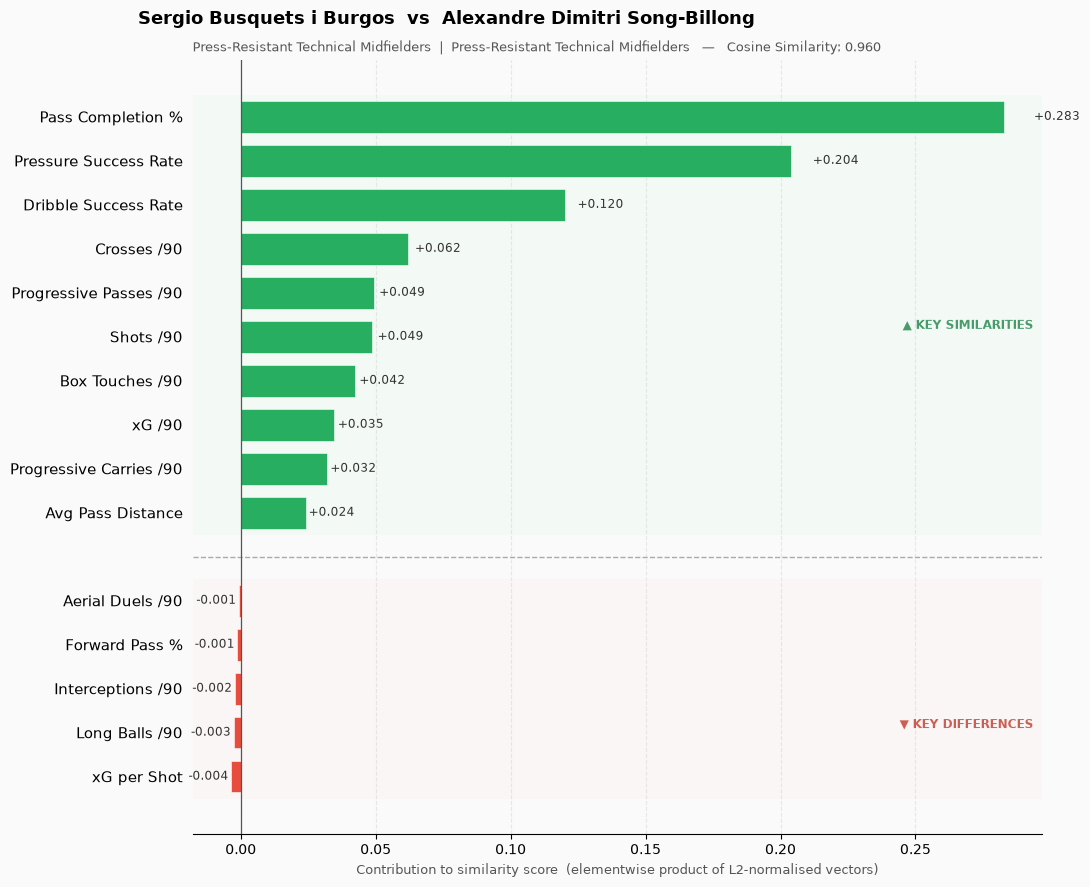

In [4]:
plot_similarity('Busquets', 'Song-Billong', save_path='../data/similarity_busquets_song.png')

**Busquets vs Song — 0.960**

The similarity is built almost entirely on *how they handle the ball*. Pass Completion % alone accounts for ~30% of the score — both are elite ball-retainers in a possession system. Pressure Success Rate adds another 20%: both press intelligently and win the ball back at similar rates. Dribble Success Rate appears high not because either is a dribbler, but because both succeed at high rates on the rare occasions they do attempt one — cosine similarity picks up the shared directional trait.

The differences are all sub -0.005, essentially noise. Busquets intercepts slightly more, Song uses slightly more long balls — but neither difference is meaningful. These players are genuinely near-identical in profile, which is the correct footballistic answer: Song was bought to play the exact same role as Busquets in Pep's system.

## Pair 2: Jordi Alba vs Patrice Evra

In [5]:
df2, cos2, row_a2, row_b2 = explain_similarity('Jordi Alba', 'Evra')

print(f"Cosine similarity: {cos2:.4f}")
print()
print("Top 10 similarities:")
print(df2.head(10)[['label', 'player_a_raw', 'player_b_raw', 'contribution']].to_string(index=False))
print()
print("Top 5 differences:")
print(df2.tail(5).sort_values('contribution')[['label', 'player_a_raw', 'player_b_raw', 'contribution']].to_string(index=False))

Cosine similarity: 0.8572

Top 10 similarities:
                label player_a_raw player_b_raw  contribution
          Crosses /90     2.403409      2.01278      0.195896
      Sideways Pass %     0.270333     0.259051      0.119864
    Pass Completion %     1.084009     0.658781      0.109778
       Forward Pass %      0.53205     0.555913      0.100519
       Key Passes /90     0.899148     0.934505      0.054961
          xG per Shot     0.126918     0.089026      0.052220
    Avg Pass Distance     16.59942    16.950871      0.051241
      Backward Pass %     0.197617     0.185036      0.046772
        Pressures /90    -0.465482    -0.596527      0.042685
Pressure Success Rate     0.241942     0.197133      0.024750

Top 5 differences:
                  label player_a_raw player_b_raw  contribution
            Tackles /90     2.339489     3.953674     -0.014967
   Dribble Success Rate     0.535156     0.346154     -0.011190
      Interceptions /90     1.453125      1.00639     -0.0

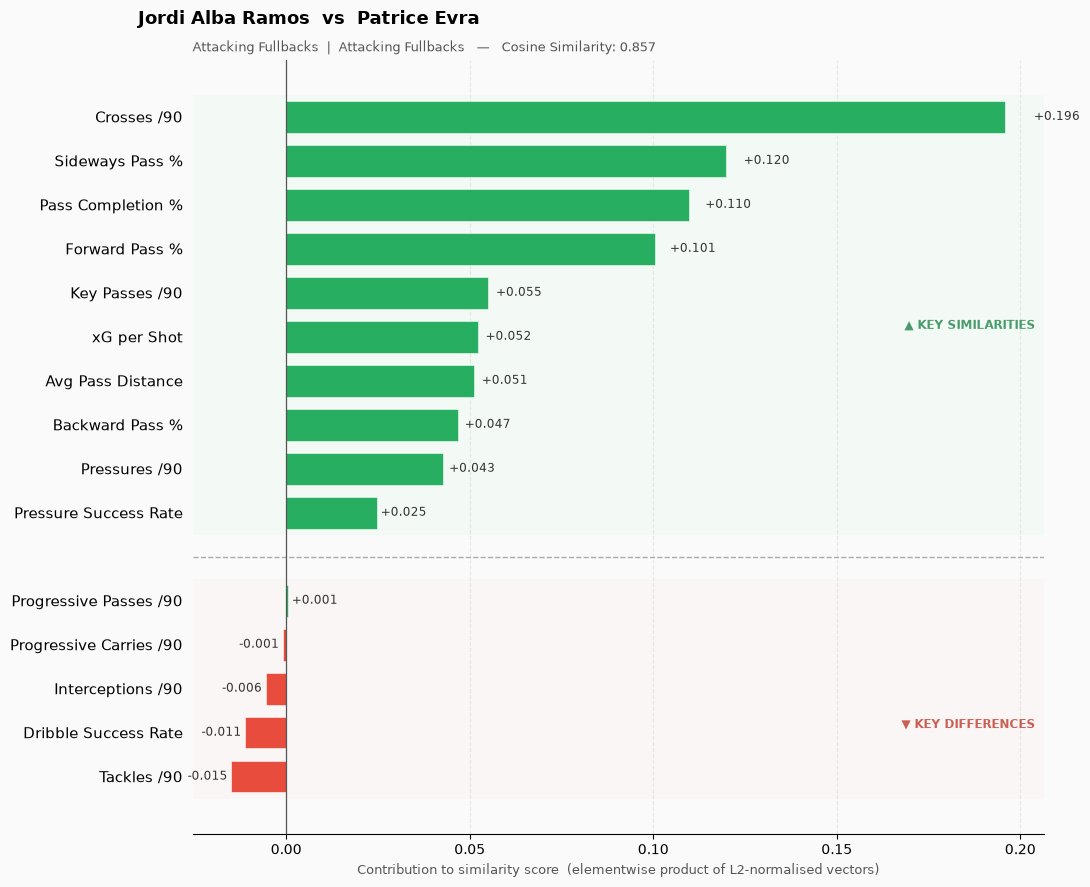

In [6]:
plot_similarity('Jordi Alba', 'Evra', save_path='../data/similarity_alba_evra.png')

**Jordi Alba vs Patrice Evra — 0.857**

The similarity is built on crossing fullback behaviour: Crosses /90 dominates at +0.196, with Pass Completion %, Forward Pass %, and Sideways Pass % combining to show two players who attack down the flank, put balls into the box, and circulate possession similarly. Both are attack-minded left backs from the same broad archetype.

The differences are where it gets interesting. Evra tackles significantly more (3.95 vs 2.34 p90) — the biggest differentiator on the chart — and his Dribble Success Rate is lower (0.35 vs 0.54). The engine is correctly capturing that Evra was the more physically defensive version of the archetype: more tackles, less technical elegance. Alba is a purer attacking outlet. 0.857 is the right score for "same archetype, different balance of attack vs defence."

## Pair 3: Suárez vs Diego Costa

In [7]:
df3, cos3, row_a3, row_b3 = explain_similarity('Suárez', 'Diego da Silva Costa')

print(f"Cosine similarity: {cos3:.4f}")
print()
print("Top 10 similarities:")
print(df3.head(10)[['label', 'player_a_raw', 'player_b_raw', 'contribution']].to_string(index=False))
print()
print("Top 5 differences:")
print(df3.tail(5).sort_values('contribution')[['label', 'player_a_raw', 'player_b_raw', 'contribution']].to_string(index=False))

Cosine similarity: 0.7537

Top 10 similarities:
                  label player_a_raw player_b_raw  contribution
        Box Touches /90     3.542329     2.635965      0.251966
                 xG /90     0.619671     0.348483      0.160482
         Forward Pass %     0.457374     0.376268      0.069039
              Shots /90      3.52524     2.221553      0.059074
            xG per Shot     0.175781     0.156865      0.058586
        Backward Pass %     0.231695     0.320487      0.054768
        Sideways Pass %     0.310931     0.303245      0.050165
Progressive Carries /90     1.909265     2.844672      0.020378
         Long Balls /90     2.467093     1.273329      0.019939
      Interceptions /90     0.207029      0.37929      0.018192

Top 5 differences:
                       label player_a_raw player_b_raw  contribution
                 Tackles /90     1.219169     5.906081     -0.028703
            Aerial Duels /90      0.64984     4.714028     -0.026863
                 Cros

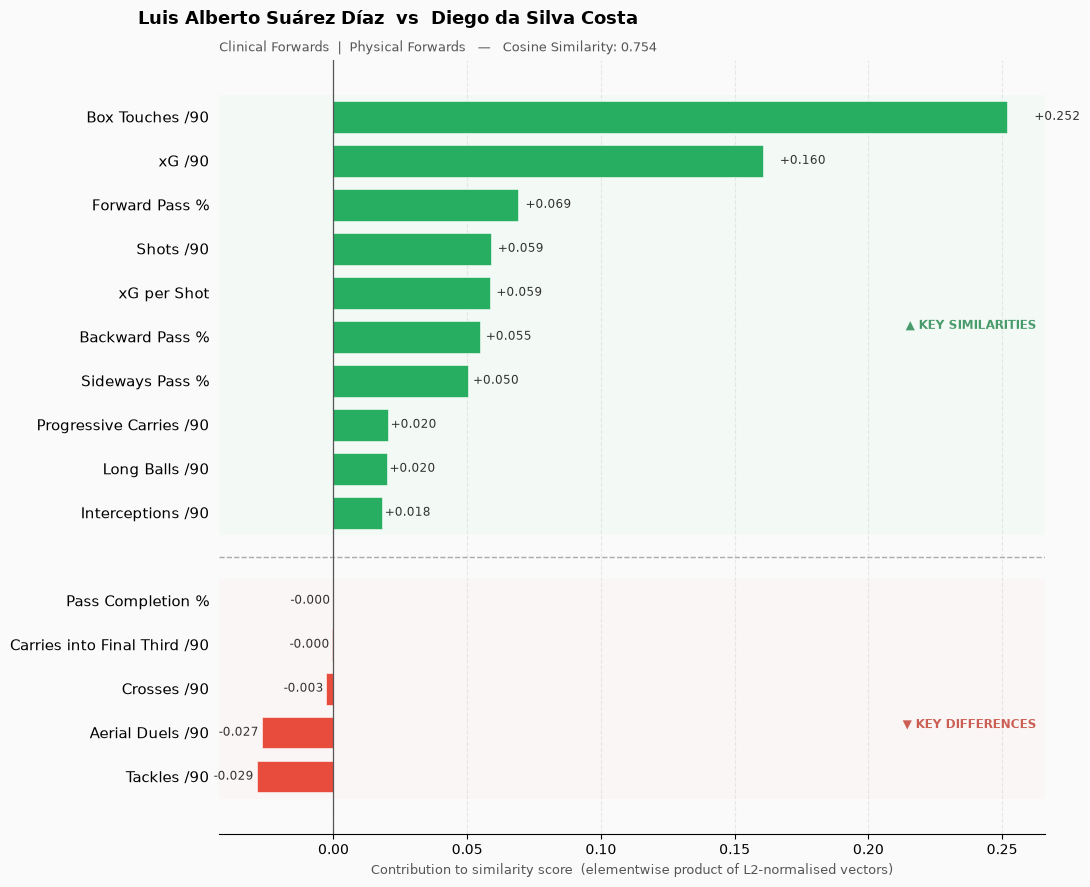

In [8]:
plot_similarity('Suárez', 'Diego da Silva Costa', save_path='../data/similarity_suarez_costa.png')

**Suárez vs Diego Costa — 0.754**

This is a *same position, very different style* pairing — and the chart captures that correctly. Both live in the box: Box Touches /90 contributes +0.252 and xG /90 adds +0.160, reflecting two strikers who generate threat at volume from close range. Shots /90, xG per Shot, and Forward Pass % reinforce that both are attack-minded finishers. That's the genuine similarity.

The differences tell the full story. The two largest red bars — Tackles /90 (-0.029) and Aerial Duels /90 (-0.027) — capture exactly how different they are in style: Costa tackles at 5.9 p90 and wins 4.7 aerial duels p90; Suárez is at 1.2 and 0.6 respectively. Costa is a physical, pressing, aerial battering ram. Suárez is a technical, dribble-based, low-aerial striker who avoids headers. 0.754 is also the right score — similar enough to appear in each other's similarity lists, different enough that a scout wouldn't confuse one for the other.